# Classification: Cane Corso Growth Status

This notebook applies the second course topic: **Classification**.

The goal is to use the processed real public dog growth sample and build classification models step by step.

The classification task will not provide veterinary diagnosis. It will only classify records into educational growth-status categories for machine learning practice.


## Course Topic Coverage

This notebook will follow the Classification lecture step by step:

1. Classification problem statement and motivation
2. Logistic Regression
3. Binary classification
4. Data preparation: encoding, scaling, train/test split, class balance
5. Evaluation: confusion matrix, accuracy, precision, recall, F1
6. ROC curve and AUC
7. Decision Trees
8. Ensemble models
9. Support Vector Machines
10. Final model comparison and interpretation


## Problem Statement

In the previous notebook, the project used regression to predict a numerical value: dog weight.

In this notebook, the task changes from predicting a number to predicting a class.

The planned classification target is `growth_status`:

- `normal_growth`
- `needs_attention`

This target will be created from body condition score information in the processed real dataset.


## Dataset

This notebook uses the processed real public dog growth sample:

`data/processed/dog_growth_public_sample.csv`

The original raw dataset is not committed to GitHub. Only the smaller processed sample is used in this notebook.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [2]:
data_path = '../data/processed/dog_growth_public_sample.csv'
df = pd.read_csv(data_path)
df.head()


,breed_id,pet_id,gender,visit_age_years,visit_age_months,weight_kg,bcs_recorded,bcs_predicted,preventive_care_visit,healthy_pet_diagnosis,average_adult_breed_weight_kg,source_type
0,11,952168,F,0.298,3.58,16.919,NaN,NaN,Y,Y,35.91,real_public_processed_sample
1,11,952169,M,0.169,2.03,7.938,Thin,NaN,N,N,35.91,real_public_processed_sample
2,11,952169,M,0.355,4.26,12.610,NaN,NaN,Y,N,35.91,real_public_processed_sample
3,11,952170,FS,0.355,4.26,16.964,NaN,NaN,N,N,35.91,real_public_processed_sample
4,11,952170,FS,0.421,5.05,21.364,NaN,NaN,Y,Y,35.91,real_public_processed_sample


## Initial Dataset Check

Before creating the classification target, I first inspect the dataset shape, columns, and basic values.


In [3]:
df.shape


(10000, 12)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   breed_id                       10000 non-null  int64  
 1   pet_id                         10000 non-null  int64  
 2   gender                         10000 non-null  str    
 3   visit_age_years                10000 non-null  float64
 4   visit_age_months               10000 non-null  float64
 5   weight_kg                      10000 non-null  float64
 6   bcs_recorded                   324 non-null    str    
 7   bcs_predicted                  421 non-null    str    
 8   preventive_care_visit          10000 non-null  str    
 9   healthy_pet_diagnosis          10000 non-null  str    
 10  average_adult_breed_weight_kg  10000 non-null  float64
 11  source_type                    10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB


In [5]:
df[['bcs_recorded', 'bcs_predicted', 'source_type']].head(10)


,bcs_recorded,bcs_predicted,source_type
0,NaN,NaN,real_public_processed_sample
1,Thin,NaN,real_public_processed_sample
2,NaN,NaN,real_public_processed_sample
3,NaN,NaN,real_public_processed_sample
4,NaN,NaN,real_public_processed_sample
5,NaN,NaN,real_public_processed_sample
6,NaN,NaN,real_public_processed_sample
7,NaN,NaN,real_public_processed_sample
8,NaN,NaN,real_public_processed_sample
9,NaN,NaN,real_public_processed_sample


## Create Classification Target

For this classification task, I create a new target column called `growth_status`.

The target is based on body condition score information:

- `Normal` becomes `normal_growth`
- `Thin` or `Heavy` becomes `needs_attention`

This is not a veterinary diagnosis. It is only an educational classification label used to practice machine learning methods.

In [6]:
df["bcs_source"] = df["bcs_recorded"]

df.loc[
    (df["bcs_source"].isna()) | (df["bcs_source"] == "None"),
    "bcs_source"
] = df["bcs_predicted"]

df["growth_status"] = df["bcs_source"].map({
    "Normal": "normal_growth",
    "Thin": "needs_attention",
    "Heavy": "needs_attention"
})

classification_df = df.dropna(subset=["growth_status"]).copy()

classification_df[["bcs_recorded", "bcs_predicted", "bcs_source", "growth_status"]].head(10)

,bcs_recorded,bcs_predicted,bcs_source,growth_status
1,Thin,NaN,Thin,needs_attention
24,NaN,Thin,Thin,needs_attention
43,Heavy,NaN,Heavy,needs_attention
84,NaN,Thin,Thin,needs_attention
126,Thin,NaN,Thin,needs_attention
127,Thin,NaN,Thin,needs_attention
128,Thin,NaN,Thin,needs_attention
130,Thin,NaN,Thin,needs_attention
131,Thin,NaN,Thin,needs_attention
132,Thin,NaN,Thin,needs_attention


In [7]:
classification_df["growth_status"].value_counts()

growth_status
needs_attention    579
normal_growth      166
Name: count, dtype: int64

In [8]:
classification_df["growth_status"].value_counts(normalize=True).round(3)

growth_status
needs_attention    0.777
normal_growth      0.223
Name: proportion, dtype: float64

In [9]:
classification_df["growth_status_binary"] = classification_df["growth_status"].map({
    "normal_growth": 0,
    "needs_attention": 1
})

classification_df[["growth_status", "growth_status_binary"]].head()

,growth_status,growth_status_binary
1,needs_attention,1
24,needs_attention,1
43,needs_attention,1
84,needs_attention,1
126,needs_attention,1


### Target Interpretation

The `growth_status_binary` column is the numeric target for binary classification.

- `0` means `normal_growth`
- `1` means `needs_attention`

This target allows the project to apply Logistic Regression and other classification models from the course.

## Logistic Regression Classifier

Logistic Regression is the first classification model in this notebook.

The model will predict whether a record belongs to:

- `normal_growth`
- `needs_attention`

The target column is `growth_status_binary`.

The model will use several input features from the processed real dog growth sample.

In [10]:
classification_features = pd.get_dummies(
    classification_df[
        [
            "visit_age_months",
            "weight_kg",
            "average_adult_breed_weight_kg",
            "gender",
            "preventive_care_visit",
            "healthy_pet_diagnosis"
        ]
    ],
    drop_first=True
)

classification_target = classification_df["growth_status_binary"]

classification_features.head()

,visit_age_months,weight_kg,average_adult_breed_weight_kg,gender_FS,gender_M,gender_MN,preventive_care_visit_Y,healthy_pet_diagnosis_Y
1,2.03,7.938,35.91,False,True,False,False,False
24,26.99,35.244,35.91,False,True,False,True,False
43,30.04,57.606,35.91,False,False,True,True,False
84,27.71,23.678,35.91,False,False,True,True,False
126,3.35,3.357,35.91,False,False,False,True,False


In [11]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    classification_features,
    classification_target,
    test_size=0.25,
    random_state=42,
    stratify=classification_target
)

print("Training rows:", X_train_cls.shape[0])
print("Test rows:", X_test_cls.shape[0])
print("Training class balance:")
print(y_train_cls.value_counts(normalize=True).round(3))
print("Test class balance:")
print(y_test_cls.value_counts(normalize=True).round(3))

Training rows: 558
Test rows: 187
Training class balance:
growth_status_binary
1    0.778
0    0.222
Name: proportion, dtype: float64
Test class balance:
growth_status_binary
1    0.775
0    0.225
Name: proportion, dtype: float64


In [12]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

logistic_model.fit(X_train_cls, y_train_cls)

logistic_predictions = logistic_model.predict(X_test_cls)
logistic_probabilities = logistic_model.predict_proba(X_test_cls)[:, 1]

In [13]:
logistic_results = pd.DataFrame({
    "actual_class": y_test_cls.values,
    "predicted_class": logistic_predictions,
    "needs_attention_probability": logistic_probabilities.round(3)
})

logistic_results.head(10)

,actual_class,predicted_class,needs_attention_probability
0,1,1,0.927
1,1,1,0.897
2,1,1,0.609
3,1,1,0.931
4,1,1,0.909
5,1,1,0.981
6,1,0,0.140
7,0,0,0.402
8,1,0,0.030
9,1,1,0.935


### Logistic Regression Notes

The Logistic Regression model predicts a binary class:

- `0` = normal growth
- `1` = needs attention

The probability column shows how confident the model is that a record belongs to the `needs_attention` class.

The next step will evaluate this classifier using confusion matrix, accuracy, precision, recall, and F1-score.

## Classification Evaluation

After training the Logistic Regression classifier, I evaluate the model using standard classification metrics.

The evaluation includes:

- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-score

These metrics help explain how well the classifier predicts `normal_growth` and `needs_attention`.

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

In [15]:
logistic_confusion_matrix = confusion_matrix(
    y_test_cls,
    logistic_predictions
)

logistic_confusion_matrix

array([[ 36,   6],
       [ 32, 113]])

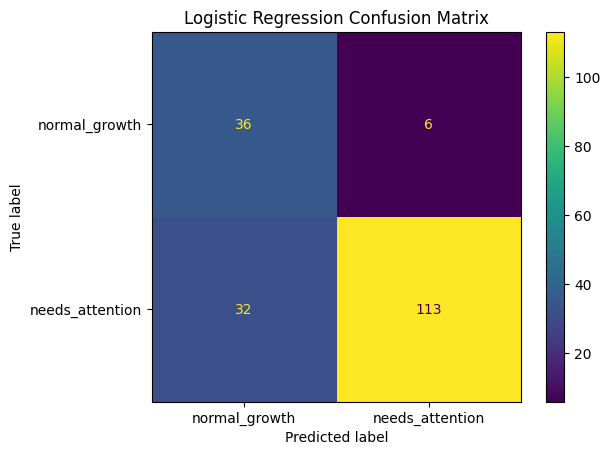

In [16]:
ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=["normal_growth", "needs_attention"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [17]:
logistic_accuracy = accuracy_score(y_test_cls, logistic_predictions)
logistic_precision = precision_score(y_test_cls, logistic_predictions, zero_division=0)
logistic_recall = recall_score(y_test_cls, logistic_predictions, zero_division=0)
logistic_f1 = f1_score(y_test_cls, logistic_predictions, zero_division=0)

logistic_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1
    ]
})

logistic_metrics

,Metric,Value
0,Accuracy,0.796791
1,Precision,0.949580
2,Recall,0.779310
3,F1-score,0.856061


In [18]:
print(
    classification_report(
        y_test_cls,
        logistic_predictions,
        target_names=["normal_growth", "needs_attention"],
        zero_division=0
    )
)

                 precision    recall  f1-score   support

  normal_growth       0.53      0.86      0.65        42
needs_attention       0.95      0.78      0.86       145

       accuracy                           0.80       187
      macro avg       0.74      0.82      0.76       187
   weighted avg       0.86      0.80      0.81       187



### Evaluation Interpretation

The confusion matrix shows how many records were classified correctly and incorrectly.

Accuracy shows the overall percentage of correct predictions.

Precision shows how many records predicted as `needs_attention` were actually `needs_attention`.

Recall shows how many actual `needs_attention` records were found by the model.

F1-score combines precision and recall into one metric.

For this project, recall is especially important because missing a `needs_attention` case may be more problematic than marking a normal case for additional review. This is still only an educational classification experiment and not a veterinary diagnosis.

## ROC Curve and AUC

The ROC curve is used to evaluate a binary classifier at different probability thresholds.

It compares:

- True Positive Rate
- False Positive Rate

The AUC score summarizes the ROC curve in a single number. A value closer to 1 means better classification performance.

In [19]:
logistic_fpr, logistic_tpr, logistic_thresholds = roc_curve(
    y_test_cls,
    logistic_probabilities
)

logistic_auc = roc_auc_score(
    y_test_cls,
    logistic_probabilities
)

logistic_auc

0.8492610837438423

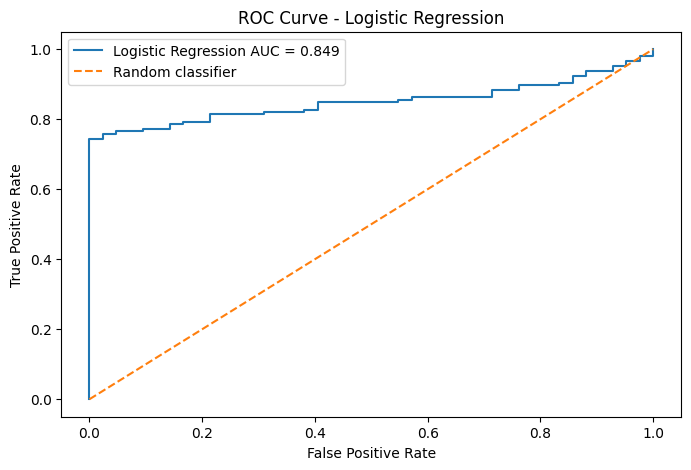

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(logistic_fpr, logistic_tpr, label=f"Logistic Regression AUC = {logistic_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### ROC / AUC Interpretation

The ROC curve shows how the classifier behaves when the decision threshold changes.

The dashed diagonal line represents a random classifier.

A curve closer to the upper-left corner means better performance.

The AUC score summarizes this behavior. In this project, it helps evaluate how well Logistic Regression separates `normal_growth` from `needs_attention`.

## Decision Tree Classifier

Decision Trees are classification models that split the data step by step.

They are easier to interpret than many other models because the final prediction is made by following a path from the root node to a leaf node.

In this experiment, I train a Decision Tree classifier and compare its results with Logistic Regression.

In [21]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight="balanced"
)

decision_tree_model.fit(X_train_cls, y_train_cls)

tree_predictions = decision_tree_model.predict(X_test_cls)
tree_probabilities = decision_tree_model.predict_proba(X_test_cls)[:, 1]

In [22]:
tree_accuracy = accuracy_score(y_test_cls, tree_predictions)
tree_precision = precision_score(y_test_cls, tree_predictions, zero_division=0)
tree_recall = recall_score(y_test_cls, tree_predictions, zero_division=0)
tree_f1 = f1_score(y_test_cls, tree_predictions, zero_division=0)
tree_auc = roc_auc_score(y_test_cls, tree_probabilities)

tree_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "Decision Tree": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_auc
    ]
})

tree_metrics

,Metric,Decision Tree
0,Accuracy,0.839572
1,Precision,0.938931
2,Recall,0.848276
3,F1-score,0.891304
4,AUC,0.831691


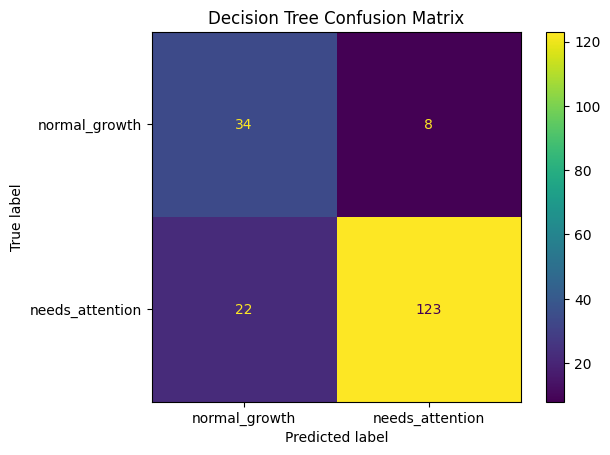

In [23]:
tree_confusion_matrix = confusion_matrix(
    y_test_cls,
    tree_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=tree_confusion_matrix,
    display_labels=["normal_growth", "needs_attention"]
).plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [24]:
tree_feature_importance = pd.DataFrame({
    "Feature": classification_features.columns,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

tree_feature_importance

,Feature,Importance
3,gender_FS,0.427735
0,visit_age_months,0.390258
1,weight_kg,0.123416
7,healthy_pet_diagnosis_Y,0.039974
4,gender_M,0.018617
2,average_adult_breed_weight_kg,0.000000
5,gender_MN,0.000000
6,preventive_care_visit_Y,0.000000


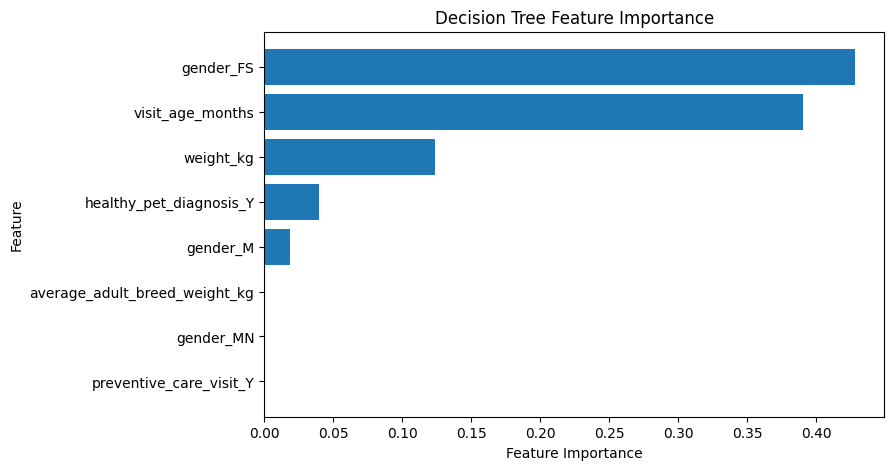

In [25]:
plt.figure(figsize=(8, 5))
plt.barh(
    tree_feature_importance["Feature"],
    tree_feature_importance["Importance"]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()

### Decision Tree Interpretation

The Decision Tree classifier provides a more interpretable model than Logistic Regression.

The feature importance table shows which input features were most useful for making classification decisions.

The `max_depth` parameter is used to limit the tree and reduce overfitting. A very deep tree may memorize the training data instead of learning a useful pattern.

This model is still used only for educational classification practice and does not provide veterinary diagnosis.